<a href="https://colab.research.google.com/github/aceram7678-blip/data/blob/main/SQLINR0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
system('git clone https://github.com/aceram7678-blip/data.git')

In [3]:
# Install and load sqldf package in R
if (!require("sqldf")) install.packages("sqldf", repos="http://cran.us.r-project.org")
library(sqldf)

Loading required package: sqldf

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘sqldf’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



In [9]:
if (!require("ggplot2")) install.packages("ggplot2", repos="http://cran.us.r-project.org")
library(ggplot2)
if (!require("scales")) install.packages("scales", repos="http://cran.us.r-project.org")
library(scales)

Loading required package: ggplot2

Loading required package: scales



In [5]:
# Load data from the cloned repository
deliveries <- read.csv("data/deliveries.csv")
orders <- read.csv("data/orders.csv")

# Display the first few rows to verify
print(head(deliveries))
print(head(orders))

  delivery_id order_id driver_id vehicle_id hub_id       dispatch_time
1     DL00001   O00938      D004       V056    H05 2024-06-18 10:57:00
2     DL00002   O00004      D138       V007    H02 2025-01-11 18:45:00
3     DL00003   O00639      D006       V049    H02 2025-06-02 20:39:00
4     DL00004   O00313      D116       V055    H02 2024-03-08 23:31:00
5     DL00005   O00844      D108       V034    H01 2025-09-21 11:43:00
6     DL00006   O00029      D037       V098    H03 2024-09-11 12:40:00
       delivery_completed_at delivery_status route_distance_km
1 2024-06-19 09:05:59.904311          Failed             17.26
2 2025-01-11 17:39:00.000000          OnTime             10.34
3 2025-06-02 21:45:32.366770          OnTime              7.92
4 2024-03-09 23:30:08.103702         Delayed             16.42
5 2025-09-21 15:45:34.131056          OnTime             14.52
6 2024-09-12 17:11:52.384869         Delayed             13.84
  manual_route_override_count proof_of_completion_missing
1   

In [12]:
drivers <- read.csv("data/drivers.csv")
print(head(drivers))

  driver_id base_zone employment_type years_experience training_score
1      D001   AIRPORT        FullTime                8           67.8
2      D002   Central        FullTime                4           42.4
3      D003   AIRPORT        FullTime               11           96.5
4      D004   Airport        PartTime               13           88.9
5      D005     north        FullTime                3           69.7
6      D006   CENTRAL        FullTime                8           78.8
  driver_rating shift_preference active_flag
1          3.54          Morning           1
2          3.94          Evening           1
3          5.00          Evening           1
4          4.75          Morning           1
5          4.14          Morning           1
6          4.38         Flexible           1


In [16]:
vehicles <- read.csv("data/vehicles.csv")
print(head(vehicles))

  vehicle_id vehicle_type assigned_zone     commission_date battery_health_pct
1       V001           EV         North 2024-12-28 23:48:00               71.8
2       V002           EV       AIRPORT 2024-04-21 16:14:00               67.9
3       V003     CargoVan         north 2025-11-24 23:59:00               91.7
4       V004       Hybrid     RiverSide 2024-06-07 13:21:00                 NA
5       V005     CargoVan          West 2025-11-15 11:08:00               58.6
6       V006           EV       Central 2025-11-22 06:39:00               78.6
  odometer_km maintenance_status telematics_version
1       56928             Active               v2.2
2      159368           InRepair               v2.2
3      219359             Active               v2.1
4       36310             Active               v2.2
5      146638             Active               v2.2
6      141381             Active               v2.1


In [21]:
complaints <- read.csv("data/complaints.csv")
print(head(complaints))

  complaint_id customer_id order_id complaint_type channel severity
1       CP0001       C0464   O00814       AppIssue     App     High
2       CP0002       C0056   O00628   MissedPickup   Phone   Medium
3       CP0003       C0469   O00384          Delay Chatbot     High
4       CP0004       C0631   O00406          Delay     App   Medium
5       CP0005       C0535   O00154          Delay   Email   Medium
6       CP0006       C0096   O00147          Delay     App   Medium
           created_at           status resolution_days compensation_amount
1 2025-03-30 02:36:00             Open              11               23.99
2 2024-11-07 10:05:00             Open               4               21.64
3 2024-01-02 15:47:00             Open              16               26.41
4 2025-01-14 13:07:00 AwaitingCustomer               7               23.44
5 2024-08-31 05:56:00         Resolved               1               16.18
6 2024-07-22 07:43:00         Resolved               9               18.51

In [25]:
hubs <- read.csv('data/hubs.csv')
print(head(hubs))

  hub_id       hub_name    zone  hub_type capacity_score
1    H01 North Exchange   North  Dispatch             82
2    H02     South Link   South  Dispatch             78
3    H03      East Dock    East Warehouse             74
4    H04      West Gate    West  Dispatch             69
5    H05   Central Core Central   Control             88
6    H06    Airport Hub Airport  Dispatch             71


In [6]:
# Join deliveries → orders to get zone context, then count delivery statuses
q1 <- sqldf("
  SELECT
    o.pickup_zone                          AS zone,
    d.delivery_status,
    COUNT(*)                               AS total,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY o.pickup_zone), 1) AS pct
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone, d.delivery_status
  ORDER BY zone, total DESC
")
print(q1)

        zone delivery_status total  pct
1    AIRPORT          OnTime    29 63.0
2    AIRPORT         Delayed    13 28.3
3    AIRPORT          Failed     4  8.7
4    Airport          OnTime    41 61.2
5    Airport         Delayed    18 26.9
6    Airport          Failed     8 11.9
7    CENTRAL          OnTime    28 50.9
8    CENTRAL         Delayed    16 29.1
9    CENTRAL          Failed    11 20.0
10   Central          OnTime    33 60.0
11   Central         Delayed    11 20.0
12   Central          Failed    11 20.0
13       Ctr          OnTime    29 45.3
14       Ctr         Delayed    24 37.5
15       Ctr          Failed    11 17.2
16      EAST          OnTime    53 67.9
17      EAST         Delayed    14 17.9
18      EAST          Failed    11 14.1
19      East          OnTime    53 67.9
20      East         Delayed    17 21.8
21      East          Failed     8 10.3
22     NORTH          OnTime    30 65.2
23     NORTH         Delayed     9 19.6
24     NORTH          Failed     7 15.2


In [7]:
# Join deliveries → orders to get zone context, then count delivery statuses
q1 <- sqldf("
  SELECT
    o.pickup_zone                          AS zone,
    d.delivery_status,
    COUNT(*)                               AS total,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY o.pickup_zone), 1) AS pct
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone, d.delivery_status
  ORDER BY zone, total DESC
")
print(q1)

        zone delivery_status total  pct
1    AIRPORT          OnTime    29 63.0
2    AIRPORT         Delayed    13 28.3
3    AIRPORT          Failed     4  8.7
4    Airport          OnTime    41 61.2
5    Airport         Delayed    18 26.9
6    Airport          Failed     8 11.9
7    CENTRAL          OnTime    28 50.9
8    CENTRAL         Delayed    16 29.1
9    CENTRAL          Failed    11 20.0
10   Central          OnTime    33 60.0
11   Central         Delayed    11 20.0
12   Central          Failed    11 20.0
13       Ctr          OnTime    29 45.3
14       Ctr         Delayed    24 37.5
15       Ctr          Failed    11 17.2
16      EAST          OnTime    53 67.9
17      EAST         Delayed    14 17.9
18      EAST          Failed    11 14.1
19      East          OnTime    53 67.9
20      East         Delayed    17 21.8
21      East          Failed     8 10.3
22     NORTH          OnTime    30 65.2
23     NORTH         Delayed     9 19.6
24     NORTH          Failed     7 15.2


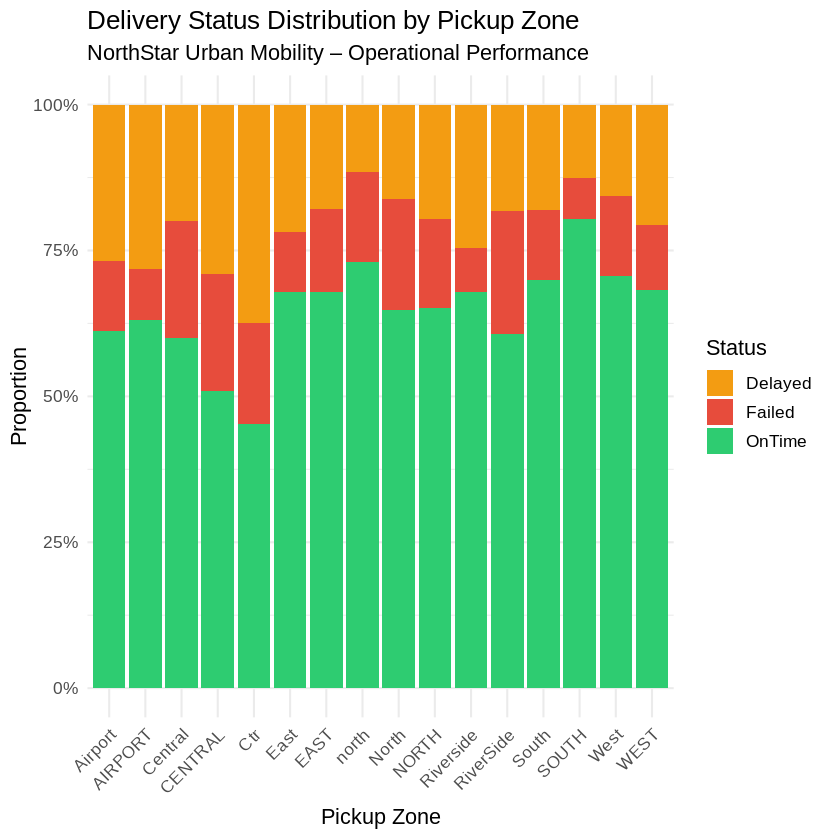

In [10]:
library(ggplot2)
library(scales)
ggplot(q1, aes(x = zone, y = total, fill = delivery_status)) +
  geom_bar(stat = "identity", position = "fill") +
  scale_y_continuous(labels = percent_format()) +
  scale_fill_manual(values = c("OnTime"  = "#2ecc71",
                                "Delayed" = "#f39c12",
                                "Failed"  = "#e74c3c")) +
  labs(title    = "Delivery Status Distribution by Pickup Zone",
       subtitle = "NorthStar Urban Mobility – Operational Performance",
       x = "Pickup Zone", y = "Proportion", fill = "Status") +
  theme_minimal(base_size = 13) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [13]:
q2 <- sqldf("
  SELECT
    base_zone                              AS zone,
    employment_type,
    COUNT(*)                               AS driver_count,
    ROUND(AVG(driver_rating), 2)           AS avg_rating,
    ROUND(AVG(training_score), 2)          AS avg_training_score,
    SUM(CASE WHEN active_flag = 1 THEN 1 ELSE 0 END) AS active_drivers
  FROM drivers
  GROUP BY base_zone, employment_type
  ORDER BY avg_rating DESC
")
print(q2)

        zone employment_type driver_count avg_rating avg_training_score
1    Airport        PartTime            2       4.72              84.10
2       WEST        PartTime            2       4.60              73.95
3        Ctr        PartTime            2       4.54              65.00
4  RiverSide        FullTime            3       4.48              76.23
5      north        PartTime            4       4.44              73.40
6      north        Contract            1       4.43              73.30
7    Central        FullTime            7       4.40              73.73
8      North        Contract            1       4.40              65.60
9  Riverside        PartTime            1       4.40              70.30
10   Airport        Contract            1       4.36                 NA
11 RiverSide        Contract            5       4.36              69.38
12     South        FullTime           15       4.34              71.62
13     SOUTH        PartTime            3       4.32            

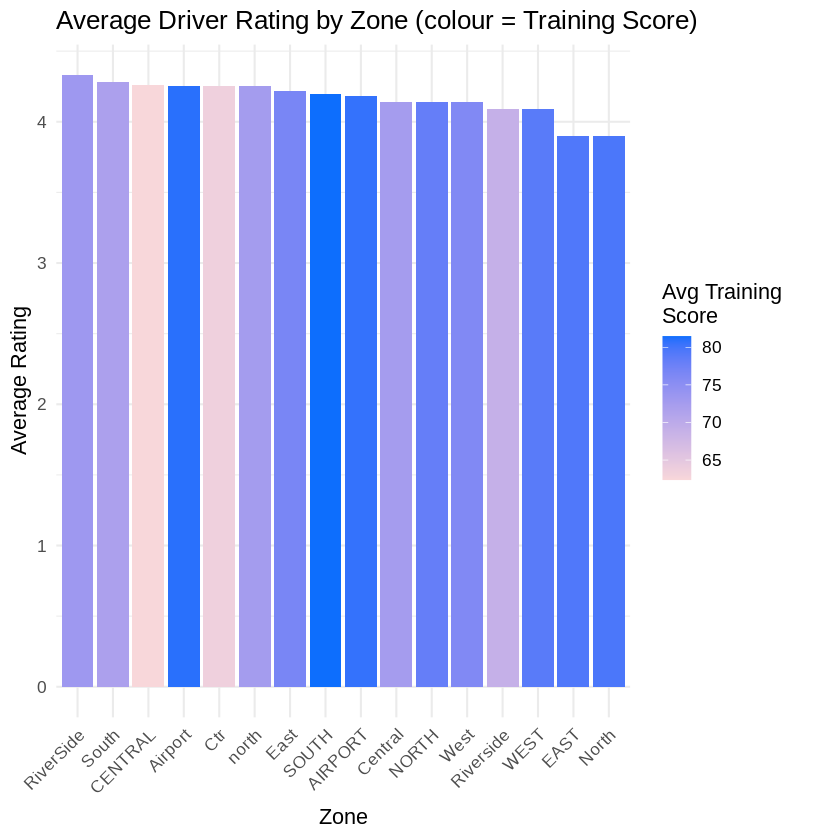

In [14]:
# Aggregate to zone level for chart clarity
driver_zone_summary <- sqldf("
  SELECT base_zone AS zone,
         ROUND(AVG(driver_rating), 2)     AS avg_rating,
         ROUND(AVG(training_score), 2)    AS avg_training,
         COUNT(*)                         AS total_drivers
  FROM drivers
  GROUP BY base_zone
  ORDER BY avg_rating DESC
")
ggplot(driver_zone_summary, aes(x = reorder(zone, -avg_rating), y = avg_rating, fill = avg_training)) +
  geom_bar(stat = "identity") +
  scale_fill_gradient(low = "#f8d7da", high = "#0d6efd") +
  labs(title  = "Average Driver Rating by Zone (colour = Training Score)",
       x = "Zone", y = "Average Rating", fill = "Avg Training\nScore") +
  theme_minimal(base_size = 13) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [17]:
q3 <- sqldf("
  SELECT
    vehicle_type,
    maintenance_status,
    COUNT(*)                               AS count,
    ROUND(AVG(battery_health_pct), 1)      AS avg_battery,
    ROUND(AVG(odometer_km), 0)             AS avg_odometer
  FROM vehicles
  WHERE battery_health_pct IS NOT NULL
  GROUP BY vehicle_type, maintenance_status
  ORDER BY vehicle_type, count DESC
")
print(q3)

   vehicle_type maintenance_status count avg_battery avg_odometer
1      CargoVan             Active    14        76.2       105835
2      CargoVan           InRepair    12        71.5       112507
3      CargoVan          Scheduled     4        69.3       138536
4        Diesel             Active    10        65.4        80713
5        Diesel           InRepair     7        75.6        91508
6        Diesel          Scheduled     2        78.6       124912
7            EV             Active    27        83.1       119493
8            EV           InRepair     8        78.5       134186
9            EV          Scheduled     6        82.4       140850
10       Hybrid             Active    12        71.9       122302
11       Hybrid           InRepair     9        82.6       122360
12       Hybrid          Scheduled     5        78.4       116865


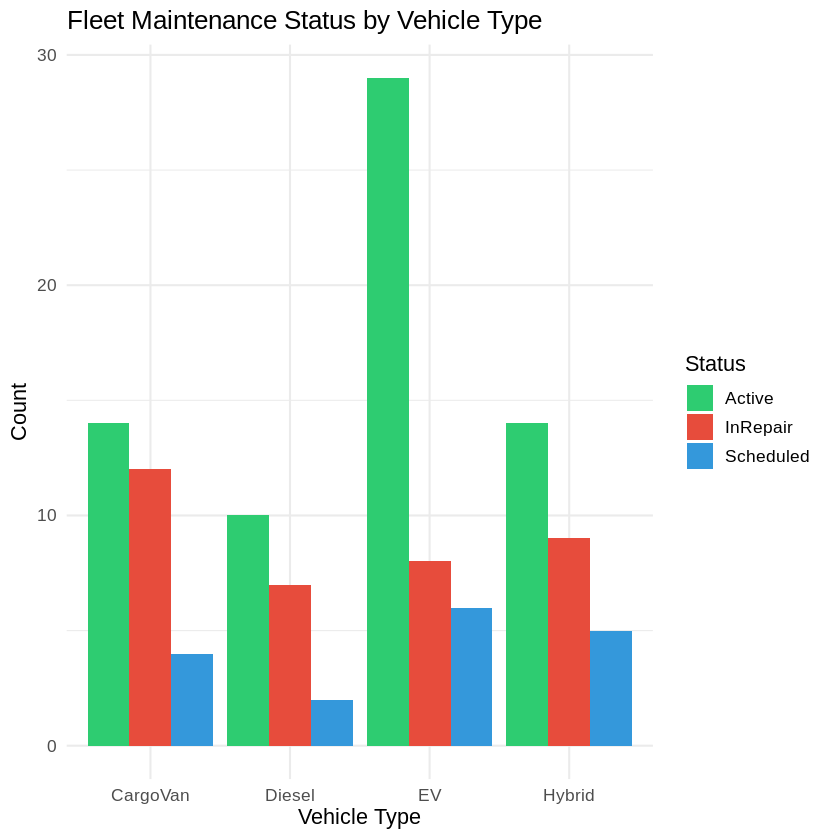

In [18]:
fleet_status <- sqldf("
  SELECT vehicle_type,
         maintenance_status,
         COUNT(*) AS n
  FROM vehicles
  GROUP BY vehicle_type, maintenance_status
")
ggplot(fleet_status, aes(x = vehicle_type, y = n, fill = maintenance_status)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("Active"    = "#2ecc71",
                                "Scheduled" = "#3498db",
                                "InRepair"  = "#e74c3c")) +
  labs(title = "Fleet Maintenance Status by Vehicle Type",
       x = "Vehicle Type", y = "Count", fill = "Status") +
  theme_minimal(base_size = 13)

In [22]:
q4 <- sqldf("
  SELECT
    complaint_type,
    severity,
    COUNT(*)                               AS total_complaints,
    ROUND(AVG(resolution_days), 1)         AS avg_resolution_days,
    ROUND(AVG(compensation_amount), 2)     AS avg_compensation,
    SUM(compensation_amount)               AS total_compensation
  FROM complaints
  GROUP BY complaint_type, severity
  ORDER BY total_complaints DESC
")
print(q4)

      complaint_type severity total_complaints avg_resolution_days
1              Delay   Medium               56                 6.0
2       MissedPickup   Medium               37                 6.2
3    DriverBehaviour   Medium               31                 5.4
4              Delay      Low               27                 6.5
5           AppIssue   Medium               25                 7.4
6              Delay     High               18                12.4
7    DriverBehaviour     High               16                13.8
8       MissedPickup     High               16                11.6
9           AppIssue      Low               15                 6.1
10          AppIssue     High               13                13.9
11 SupportExperience   Medium               12                 6.2
12      MissedPickup      Low               11                 6.9
13           Billing   Medium                9                 5.8
14            Damage     High                7                

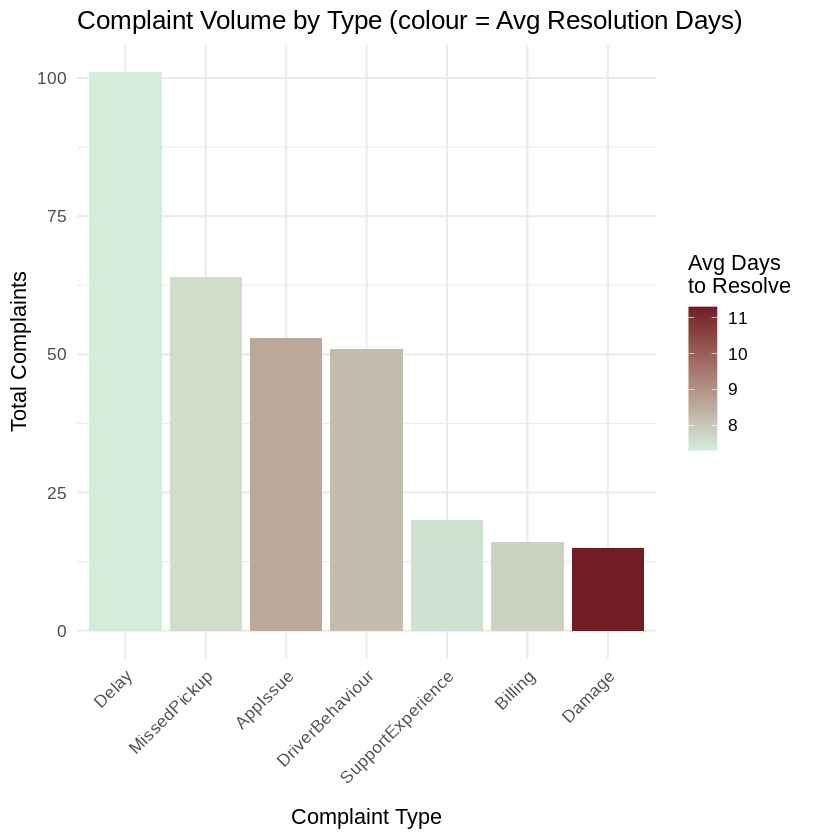

In [23]:
complaint_summary <- sqldf("
  SELECT complaint_type,
         COUNT(*) AS n,
         ROUND(AVG(resolution_days), 1) AS avg_days
  FROM complaints
  GROUP BY complaint_type
  ORDER BY n DESC
")
ggplot(complaint_summary, aes(x = reorder(complaint_type, -n), y = n, fill = avg_days)) +
  geom_bar(stat = "identity") +
  scale_fill_gradient(low = "#d4edda", high = "#721c24") +
  labs(title  = "Complaint Volume by Type (colour = Avg Resolution Days)",
       x = "Complaint Type", y = "Total Complaints", fill = "Avg Days\nto Resolve") +
  theme_minimal(base_size = 13) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [26]:
q5 <- sqldf("
  SELECT
    h.hub_id,
    h.hub_name,
    h.zone,
    h.hub_type,
    h.capacity_score,
    COUNT(d.delivery_id)                   AS total_dispatches,
    ROUND(AVG(d.route_distance_km), 2)     AS avg_route_km,
    SUM(d.manual_route_override_count)     AS total_overrides,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating
  FROM hubs h
  LEFT JOIN deliveries d ON h.hub_id = d.hub_id
  GROUP BY h.hub_id, h.hub_name, h.zone, h.hub_type, h.capacity_score
  ORDER BY total_dispatches DESC
")
print(q5)

  hub_id       hub_name      zone  hub_type capacity_score total_dispatches
1    H01 North Exchange     North  Dispatch             82              136
2    H08  Midtown Relay   Central  Charging             63              128
3    H04      West Gate      West  Dispatch             69              127
4    H03      East Dock      East Warehouse             74              119
5    H05   Central Core   Central   Control             88              115
6    H07  Riverside Hub Riverside Warehouse             66              115
7    H02     South Link     South  Dispatch             78              106
8    H06    Airport Hub   Airport  Dispatch             71              104
  avg_route_km total_overrides avg_customer_rating
1        13.64             140                3.84
2        12.82             142                3.88
3        13.38             111                3.92
4        14.52             106                3.90
5        14.32             109                3.67
6        1

In [27]:
q6 <- sqldf("
  SELECT
    d.delivery_status,
    COUNT(d.delivery_id)                   AS deliveries,
    COUNT(i.incident_id)                   AS incidents_linked,
    ROUND(COUNT(i.incident_id) * 100.0 / COUNT(d.delivery_id), 1) AS incident_pct,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides,
    SUM(d.proof_of_completion_missing)     AS missing_proof_count
  FROM deliveries d
  LEFT JOIN incidents i ON d.delivery_id = i.delivery_id
  GROUP BY d.delivery_status
  ORDER BY deliveries DESC
")
print(q6)

ERROR: Error: no such table: incidents


In [28]:
incidents <- read.csv('data/incidents.csv')
print(head(incidents))

  incident_id delivery_id    incident_type         reported_at severity
1       I0001     DL00221     BatteryAlert 2024-03-11 23:46:00   Medium
2       I0002     DL00578     BatteryAlert 2024-02-21 10:56:00      Low
3       I0003     DL00175 TemperatureIssue 2025-04-17 23:22:00   Medium
4       I0004     DL00417     ProofMissing 2025-02-09 00:16:00   Medium
5       I0005     DL00897   RouteDeviation 2025-01-04 02:49:00      Low
6       I0006     DL00634   CustomerNoShow 2025-08-08 21:26:00     High
  resolution_status resolved_hours
1         Escalated           12.3
2              Open            9.6
3              Open           22.0
4            Closed            9.8
5              Open           13.0
6     PendingVendor           19.9


In [30]:
customers <- read.csv('data/customers.csv')
print(head(customers))

  customer_id age home_zone customer_type         signup_date loyalty_score
1       C0001  26     North           SME 2024-11-27 04:25:00          44.9
2       C0002  61   AIRPORT      Consumer 2025-10-28 01:04:00          55.4
3       C0003  66      East      Consumer 2025-07-02 03:23:00          75.9
4       C0004  75   CENTRAL      Consumer 2025-08-19 01:58:00          32.5
5       C0005  26 Riverside      Consumer 2025-06-03 06:02:00          55.9
6       C0006  41      WEST      Consumer 2024-03-29 13:26:00          39.9
  app_engagement_score preferred_channel account_status
1                 69.2               App         Active
2                 66.6               App         Active
3                 33.8                           Active
4                 33.0               App         Active
5                100.0               Web         Active
6                 43.3               Web         Active


In [31]:
q7 <- sqldf("
  SELECT
    c.customer_id,
    c.home_zone,
    c.customer_type,
    c.loyalty_score,
    COUNT(o.order_id)              AS total_orders,
    ROUND(SUM(o.order_value), 2)   AS total_spend,
    COUNT(cp.complaint_id)         AS total_complaints,
    ROUND(AVG(cp.compensation_amount), 2) AS avg_compensation
  FROM customers c
  LEFT JOIN orders o  ON c.customer_id = o.customer_id
  LEFT JOIN complaints cp ON c.customer_id = cp.customer_id
  GROUP BY c.customer_id, c.home_zone, c.customer_type, c.loyalty_score
  ORDER BY total_spend DESC
  LIMIT 10
")
print(q7)

   customer_id home_zone customer_type loyalty_score total_orders total_spend
1        C0545     SOUTH      Consumer          66.9           18     2770.35
2        C0372      West      Consumer          26.2           18     2007.33
3        C0172     north      Consumer          75.4           12     1727.52
4        C0157   CENTRAL      Consumer          67.9            8     1440.08
5        C0622 RiverSide      Consumer          54.2           12     1402.42
6        C0476     NORTH      Consumer          66.0           10     1175.72
7        C0023     South      Consumer          73.1           12     1165.98
8        C0335     NORTH           SME          45.3           12     1045.60
9        C0421   CENTRAL      Consumer          59.0            9      995.73
10       C0529 Riverside           SME          43.2           10      946.20
   total_complaints avg_compensation
1                18            24.53
2                18            23.96
3                12            

In [32]:
# This query uses filtering early to reduce rows before aggregation (optimisation)
q8 <- sqldf("
  SELECT
    o.service_type,
    o.priority_level,
    COUNT(d.delivery_id)                     AS total_deliveries,
    ROUND(AVG(d.fuel_or_charge_cost), 2)     AS avg_fuel_cost,
    ROUND(AVG(d.route_distance_km), 2)       AS avg_distance_km,
    ROUND(AVG(d.fuel_or_charge_cost) /
          NULLIF(AVG(d.route_distance_km),0), 4) AS cost_per_km,
    ROUND(AVG(o.order_value), 2)             AS avg_order_value,
    ROUND(AVG(o.order_value) - AVG(d.fuel_or_charge_cost), 2) AS avg_gross_margin
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  WHERE d.delivery_status IN ('OnTime', 'Delayed', 'Failed')
  GROUP BY o.service_type, o.priority_level
  ORDER BY avg_gross_margin DESC
")
print(q8)

   service_type priority_level total_deliveries avg_fuel_cost avg_distance_km
1     Passenger           High               61         12.73           13.04
2      Business       Critical               10         11.98           10.63
3     Passenger       Critical               19         10.97           12.34
4      Business         Medium               55         13.41           13.38
5        Parcel           High               62         12.89           14.25
6     Passenger            Low               77         12.15           13.14
7      Business            Low               26         12.71           15.85
8       Medical         Medium               40         13.62           13.24
9     Passenger         Medium              105         12.65           14.48
10     Business           High               35         13.37           13.24
11       Retail         Medium               97         13.40           14.03
12      Medical           High               21         11.85   

In [34]:
cat("=== NorthStar SQL in R Summary ===\n\n")
cat("Total Orders:", nrow(orders), "\n")
cat("Total Deliveries:", nrow(deliveries), "\n")
cat("Failed Deliveries:", nrow(deliveries[deliveries$delivery_status == "Failed",]), "\n")
cat("Delayed Deliveries:", nrow(deliveries[deliveries$delivery_status == "Delayed",]), "\n")
cat("Total Complaints:", nrow(complaints), "\n")
cat("Total Incidents:", nrow(incidents), "\n")
cat("Active Vehicles:", nrow(vehicles[vehicles$maintenance_status == "Active",]), "\n")
cat("Vehicles InRepair:", nrow(vehicles[vehicles$maintenance_status == "InRepair",]), "\n")

=== NorthStar SQL in R Summary ===

Total Orders: 1250 
Total Deliveries: 950 
Failed Deliveries: 132 
Delayed Deliveries: 202 
Total Complaints: 320 
Total Incidents: 280 
Active Vehicles: 67 
Vehicles InRepair: 36 
